In [ ]:
import numpy as np
import pandas as pd


In [ ]:
def sigmoid(z):
  return 1/(1+ np.exp(-z))

In [ ]:
df= pd.DataFrame([[0,0,0],[1,1,0],[0,1,1],[1,0,1]]*1000)


In [ ]:
df.columns=['x1','x2','y']

In [ ]:
df

,x1,x2,y
0,0,0,0
1,1,1,0
2,0,1,1
3,1,0,1
4,0,0,0
...,...,...,...
3995,1,0,1
3996,0,0,0
3997,1,1,0
3998,0,1,1


In [ ]:
df['x1']+= np.random.normal(size=4000)*0.1
df['x2']+= np.random.normal(size=4000)*0.1
df.head

<bound method NDFrame.head of             x1        x2  y
0     0.091476  0.015199  0
1     0.873874  0.730504  0
2     0.213026  1.142301  1
3     1.027041  0.156457  1
4     0.009663 -0.106087  0
...        ...       ... ..
3995  1.050119  0.029114  1
3996 -0.159347 -0.035326  0
3997  1.005577  0.906591  0
3998  0.047950  1.029564  1
3999  0.823898 -0.118658  1

[4000 rows x 3 columns]>

<Axes: xlabel='x1', ylabel='x2'>

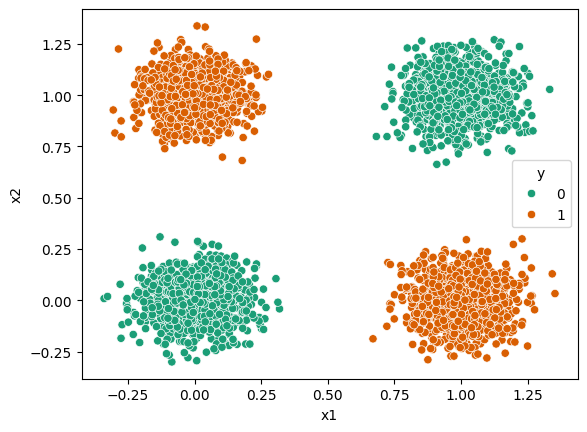

In [ ]:
import seaborn as sns
sns.scatterplot(data=df, x='x1', y='x2', hue='y', palette='Dark2')

In [ ]:
from sklearn.model_selection import train_test_split
train,test=train_test_split(df,test_size=0.3,random_state=42)
print(train.shape)
print(test.shape)
print(df.shape)

(2800, 3)
(1200, 3)
(4000, 3)


In [ ]:
W=np.array([[1,-1,0.],[-1,1,0.]])
U=np.array([1,1,0])
# w is 2X3 matrix


In [ ]:
np.array([1,2]).reshape((2,1))@np.array([3,4,5]).reshape(1,3)


array([[ 3,  4,  5],
       [ 6,  8, 10]])

In [ ]:
lr = 0.001 #Learning rate

for rep in range(500):
    toterr=0.0
    DUf = U*0.0
    DWf = W*0.0
    w11,w21,b1 = W[0]
    w12,w22,b2 = W[1]
    u1, u2, c = U
    for index, row in train.iterrows():
        x1, x2, y = row
        A1 = sigmoid(w11*x1 + w21*x2 + b1)
        A2 = sigmoid(w12*x1 + w22*x2 + b2)
        A3 = sigmoid(u1*A1 + u2*A2 + c)
        err = A3 - y
        DUf += err*np.array([A1,A2,1])
        DWf += err*np.array([u1*A1*(1-A1), u2*A2*(1-A2)]).reshape((2,1)) @ np.array([x1,x2,1]).reshape(1,3)
        toterr += err**2
    U = U - lr*DUf
    W = W - lr*DWf
    if rep%10 == 0:
        print(rep, toterr)

0 852.7214070246324
10 683.1746404441776
20 661.2176768180506
30 611.1502242627407
40 506.73557760649453
50 352.3535748730155
60 211.27434418949443
70 122.26802625746357
80 73.89663221897148
90 47.70362672493281
100 32.78464562578504
110 23.75354024702405
120 17.968249344779622
130 14.07660946392189
140 11.348496271740741
150 9.368444771956648
160 7.888523515306023
170 6.7544263699146425
180 5.8665146733227
190 5.158341687181598
200 4.584323705763294
210 4.112399521595764
220 3.719515062343176
230 3.3887635715181688
240 3.1075262386477367
250 2.866234429740017
260 2.657527959839492
270 2.475671517040162
280 2.3161428856721917
290 2.17533768846594
300 2.0503545384974453
310 1.9388365736538429
320 1.8388531108952935
330 1.7488102383581325
340 1.6673825439376928
350 1.5934604634370924
360 1.5261092974762562
370 1.4645370345033217
380 1.4080688828363583
390 1.3561269596560832
400 1.3082139771159993
410 1.2639000509758218
420 1.2228119666122799
430 1.1846243924711175
440 1.1490526470386382


In [ ]:
def predict(data):
    output = []
    w11, w21, b1 = W[0]
    w12, w22, b2 = W[1]
    u1, u2, c = U

    for index, row in data.iterrows():
        x1, x2, _ = row[:3]
        A1 = sigmoid(w11*x1 + w21*x2 + b1)
        A2 = sigmoid(w12*x1 + w22*x2 + b2)
        A3 = sigmoid(u1*A1 + u2*A2 + c)
        output.append(np.round(A3))
    return pd.Series(output, index=data.index)

test['y_pred'] = predict(test)

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(test['y'], test['y_pred']))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       593
           1       1.00      1.00      1.00       607

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200

